Mục tiêu: Kiểm định H0₁ và H0₂ — xác định việc dời gate 30→40 có làm thay đổi retention D1 và D7 một cách có ý nghĩa thống kê hay không (χ² + effect size + CI, đọc dưới ngưỡng Bonferroni).

Ngày phân tích: 2026-08-07

Step 1: Import thư viện và cố định seed

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import chi2 as chi2_dist
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Environment ready.')

Environment ready.


Step 2: Load mart (SQL Server, fallback CSV replicate policy)

In [4]:
def load_from_sql():
    import os
    from dotenv import load_dotenv
    import pyodbc
    load_dotenv()
    conn = pyodbc.connect(
        f"DRIVER={{{os.getenv('DB_DRIVER')}}};"
        f"SERVER={os.getenv('DB_SERVER')};DATABASE={os.getenv('DB_NAME')};"
        f"Trusted_Connection={os.getenv('DB_TRUSTED_CONNECTION','yes')};"
    )
    q = ("SELECT userid, version, sum_gamerounds, retention_1, retention_7, "
         "log_sum_gamerounds, engagement_bucket FROM cookie_cats.mart_ab_test_base")
    return pd.read_sql(q, conn)

def load_from_csv():
    raw = pd.read_csv('../data/cookie_cats.csv')
    g = (raw.groupby('userid')
            .agg(version=('version','max'),
                 sum_gamerounds=('sum_gamerounds','max'),
                 retention_1=('retention_1','max'),
                 retention_7=('retention_7','max'))
            .reset_index())
    mart = g[g['sum_gamerounds'] != 49854].copy()
    mart['retention_1'] = mart['retention_1'].astype(int)
    mart['retention_7'] = mart['retention_7'].astype(int)
    return mart

try:
    mart = load_from_sql()
    SOURCE = 'SQL Server (cookie_cats.mart_ab_test_base)'
except Exception as e:
    mart = load_from_csv()
    SOURCE = 'CSV fallback (mart policy replicated in pandas)'

print(f'Source: {SOURCE}')
print(f'Rows: {len(mart):,}  | columns: {list(mart.columns)}')
assert len(mart) == 90188, 'Row count khac 90,188 — kiem tra lai mart policy!'
mart[['version','sum_gamerounds','retention_1','retention_7']].head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_24340\1479998170.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(q, conn)


Source: SQL Server (cookie_cats.mart_ab_test_base)
Rows: 90,188  | columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7', 'log_sum_gamerounds', 'engagement_bucket']


,version,sum_gamerounds,retention_1,retention_7
0,gate_30,3,0,0
1,gate_30,38,1,0
2,gate_40,165,1,0
3,gate_40,1,0,0
4,gate_40,179,1,1


STEP 3: Chạy SRM guardrail trước khi phân tích (alpha=0.001)

In [5]:
n30 = int((mart['version'] == 'gate_30').sum())
n40 = int((mart['version'] == 'gate_40').sum())
n = n30 + n40
chi2_srm = (n30 - n40) ** 2 / n   # (da fix bug DEC-07: he so k=1)
p_srm = 1 - chi2_dist.cdf(chi2_srm, df=1)

print(f'gate_30 = {n30:,}  | gate_40 = {n40:,}  | total = {n:,}')
print(f'SRM chi2 = {chi2_srm:.3f}  | p = {p_srm:.4f}')
srm_ok = p_srm >= 0.001
print('SRM PASS (p >= 0.001) -> continue analysis.' if srm_ok
      else 'SRM FAIL -> STOP, escalate.')
assert srm_ok, 'SRM broken — dừng phân tích.'

gate_30 = 44,699  | gate_40 = 45,489  | total = 90,188
SRM chi2 = 6.920  | p = 0.0085
SRM PASS (p >= 0.001) -> continue analysis.


Setp 4: Định nghĩa hàm phân tích retention (chi2 + effect size + CI)

In [6]:
# STEP 4: Định nghĩa hàm phân tích retention (chi2 + effect size + CI)
def analyze_retention(df, metric):
    ct = pd.crosstab(df['version'], df[metric])
    r30 = df.loc[df.version == 'gate_30', metric].mean()
    r40 = df.loc[df.version == 'gate_40', metric].mean()

    chi2_y, p_y, dof, expected = stats.chi2_contingency(ct, correction=True)
    chi2_n, p_n, _, _          = stats.chi2_contingency(ct, correction=False)

    diff = r40 - r30
    rel  = diff / r30 * 100
    se   = np.sqrt(r30*(1-r30)/n30 + r40*(1-r40)/n40)
    ci_lo, ci_hi = diff - 1.96*se, diff + 1.96*se
    cohen_h = 2*np.arcsin(np.sqrt(r40)) - 2*np.arcsin(np.sqrt(r30))

    return dict(metric=metric, contingency=ct, expected=expected,
                rate_30=r30, rate_40=r40, diff=diff, rel_lift=rel,
                chi2_yates=chi2_y, p_yates=p_y, chi2_nocorr=chi2_n, p_nocorr=p_n,
                ci=(ci_lo, ci_hi), cohen_h=cohen_h, min_expected=expected.min())

res_d1 = analyze_retention(mart, 'retention_1')
res_d7 = analyze_retention(mart, 'retention_7')

for r in (res_d1, res_d7):
    print(f"{r['metric']}: min expected count = {r['min_expected']:,.1f}  "
          f"({'Giả định Chi2 thỏa mãn' if r['min_expected'] >= 5 else 'VI PHAM'})")

retention_1: min expected count = 19,900.6  (Giả định Chi2 thỏa mãn)
retention_7: min expected count = 8,316.5  (Giả định Chi2 thỏa mãn)


Step 5:  Khai báo ngưỡng alpha và Bonferroni cho 3 test

In [7]:
ALPHA = 0.05
N_TESTS = 3
ALPHA_BONF = ALPHA / N_TESTS
print(f'alpha goc = {ALPHA} | so test = {N_TESTS} | alpha Bonferroni = {ALPHA_BONF:.4f}')

alpha goc = 0.05 | so test = 3 | alpha Bonferroni = 0.0167


Step 6: tổng hợp kết quả D1/D7 thành bảng Verdict

In [8]:
def verdict(p):
    if p < ALPHA_BONF: return 'SIGNIFICANT (vuot ca Bonferroni)'
    if p < ALPHA:      return 'significant o 0.05 nhung KHONG vuot Bonferroni'
    return 'KHONG significant'

rows = []
for r in (res_d1, res_d7):
    rows.append({
        'Metric': r['metric'],
        'gate_30': f"{r['rate_30']*100:.2f}%",
        'gate_40': f"{r['rate_40']*100:.2f}%",
        'Diff (pp)': f"{r['diff']*100:+.3f}",
        'Rel lift': f"{r['rel_lift']:+.2f}%",
        '95% CI (pp)': f"[{r['ci'][0]*100:+.3f}, {r['ci'][1]*100:+.3f}]",
        "Cohen's h": f"{r['cohen_h']:+.4f}",
        'chi2 (Yates)': f"{r['chi2_yates']:.3f}",
        'p (Yates)': f"{r['p_yates']:.5f}",
        'Ket luan': verdict(r['p_yates']),
    })
summary = pd.DataFrame(rows)
summary

,Metric,gate_30,gate_40,Diff (pp),Rel lift,95% CI (pp),Cohen's h,chi2 (Yates),p (Yates),Ket luan
0,retention_1,44.82%,44.23%,-0.592,-1.32%,"[-1.240, +0.057]",-0.0119,3.170,0.07501,KHONG significant
1,retention_7,19.02%,18.20%,-0.818,-4.30%,"[-1.326, -0.310]",-0.0210,9.915,0.00164,SIGNIFICANT (vuot ca Bonferroni)


Step 7: Vẽ bar chart retention ± 95% CI và lưu file

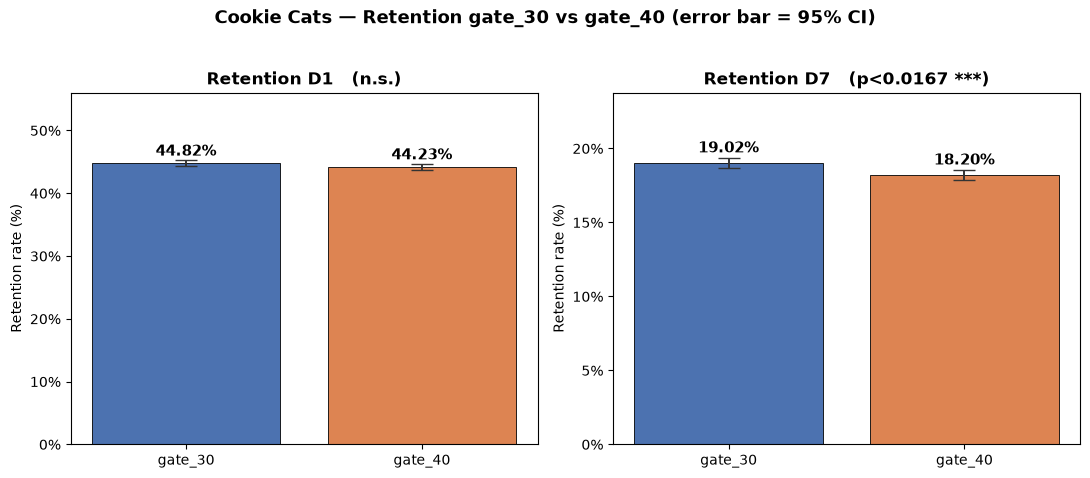

Saved: reports/phase4_g1_retention_ci.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
colors = {'gate_30': '#4C72B0', 'gate_40': '#DD8452'}

for ax, r, title in zip(axes, (res_d1, res_d7), ('Retention D1', 'Retention D7')):
    groups = ['gate_30', 'gate_40']
    rates  = [r['rate_30']*100, r['rate_40']*100]
    errs = [1.96*np.sqrt(p/100*(1-p/100)/nn)*100
            for p, nn in zip(rates, (n30, n40))]
    bars = ax.bar(groups, rates, yerr=errs, capsize=8,
                  color=[colors[g] for g in groups], edgecolor='black', linewidth=0.6,
                  error_kw=dict(ecolor='#333', lw=1.4))
    for b, v in zip(bars, rates):
        ax.text(b.get_x()+b.get_width()/2, v+max(errs)*1.3, f'{v:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    sig = 'p<0.0167 ***' if r['p_yates'] < ALPHA_BONF else ('p<0.05 *' if r['p_yates']<ALPHA else 'n.s.')
    ax.set_title(f"{title}   ({sig})", fontsize=12, fontweight='bold')
    ax.set_ylabel('Retention rate (%)')
    ax.set_ylim(0, max(rates)*1.25)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
    ax.grid(axis='y', alpha=0.3)
    ax.grid(False)

fig.suptitle('Cookie Cats — Retention gate_30 vs gate_40 (error bar = 95% CI)',
             fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
fig.savefig('../reports/phase4_g1_retention_ci.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: reports/phase4_g1_retention_ci.png')